# Notebook 06: Comprehensive Radiomic Feature Extraction

## Purpose

This notebook extracts comprehensive radiomic features from MRI volumes using PyRadiomics
and evaluates whether texture, shape, and higher-order intensity descriptors improve
survival prediction beyond the clinical and molecular features established in Notebooks 02-03.

In Notebook 04, we showed that simple pre-extracted imaging statistics (volume, mean intensity)
did not improve prediction (AUC 0.72 vs 0.72, p=0.94). Here we test whether **comprehensive**
radiomic features (GLCM texture, GLRLM run-length, shape descriptors) capture prognostic
information missed by those simple statistics.

## Theoretical Foundation

Radiomics is the high-throughput extraction of quantitative features from medical images.
The core hypothesis is that tumour biology (cell density, necrosis, vascularity, infiltration)
manifests as measurable patterns in imaging intensity distributions and spatial arrangements
that are invisible to the human eye but detectable through mathematical analysis.

PyRadiomics extracts features in several families:
- **First-order statistics**: Intensity histogram descriptors (mean, entropy, skewness, kurtosis)
- **Shape features**: 3D morphology (sphericity, elongation, surface area, compactness)
- **GLCM (Grey-Level Co-occurrence Matrix)**: Spatial intensity relationships (Haralick et al., 1973)
- **GLRLM (Grey-Level Run-Length Matrix)**: Consecutive same-intensity voxel patterns (Galloway, 1975)
- **GLSZM (Grey-Level Size Zone Matrix)**: Connected region statistics (Thibault et al., 2009)
- **GLDM (Grey-Level Dependence Matrix)**: Neighbourhood dependency patterns

## Notebook Dependencies

- **Inputs**: MRI NIfTI volumes + segmentation masks from MU-Glioma-Post; clinical data pickle from Notebook 01
- **Outputs**: Radiomic feature matrix, model comparison results, figures with `06_` prefix
- **Preceding notebooks**: 01 (preprocessing), 02 (binary classification baseline), 04 (simple radiomics)

---
## 1. Environment Setup

In [2]:
# PyRadiomics cannot build on Python 3.12+ due to deprecated configparser.SafeConfigParser
# Workaround: install from the community-patched fork, or clone and patch manually

import sys
print(f"Python version: {sys.version}")

# Method 1: Install from the patched GitHub fork (try this first)
!pip install numpy SimpleITK -q
!pip install git+https://github.com/Kozmosa/pyradiomics-fix-configparser.git -q

# If Method 1 fails, try Method 2: clone, patch, and install from source
# !git clone https://github.com/AIM-Harvard/pyradiomics.git /content/pyradiomics
# !cd /content/pyradiomics && sed -i 's/SafeConfigParser/ConfigParser/g' versioneer.py
# !cd /content/pyradiomics && sed -i "s/readfp/read_file/g" versioneer.py
# !cd /content/pyradiomics && pip install . -q

!pip install lifelines

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 18.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1747a5daf8cb99b5cb5584b2f90401659695db94ef74ad964d1090b0f99eb3fa
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
# Core imports
import os
import glob
import json
import time
import re
import warnings
import logging

# Data handling
import numpy as np
import pandas as pd
import pickle

# Medical imaging
import nibabel as nib
import SimpleITK as sitk  # PyRadiomics uses SimpleITK internally

# Radiomics
from radiomics import featureextractor

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score
from xgboost import XGBClassifier

# Statistical testing
from scipy import stats

In [4]:
# Suppress PyRadiomics verbose logging
# Set to WARNING to only see important messages during extraction
logger = logging.getLogger('radiomics')
logger.setLevel(logging.WARNING)

# General settings
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Environment setup complete.')

Environment setup complete.


---
## 2. Path Configuration and Data Loading

In [6]:
# Mount Google Drive (Colab only; comment out for local/cluster runs)
from google.colab import drive, userdata
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Path configuration
GLIOMA_DIR = userdata.get('GLIOMA_DIR')
MU_GLIOMA_DIR = os.path.join(GLIOMA_DIR, 'MU_Glioma_Post')

# Directories for loading preprocessed data from previous notebooks
PREPROCESSED_DIR = os.path.join(GLIOMA_DIR, 'preprocessed')

# Output directories for this notebook
RESULTS_DIR = os.path.join(GLIOMA_DIR, 'pyradiomics', 'results')
FIGURES_DIR = os.path.join(GLIOMA_DIR, 'pyradiomics', 'figures')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Verify paths exist
for path, label in [(GLIOMA_DIR, 'GLIOMA_DIR'),
                     (MU_GLIOMA_DIR, 'MU_GLIOMA_DIR'),
                     (PREPROCESSED_DIR, 'PREPROCESSED_DIR')]:
    exists = os.path.exists(path)
    print(f'{label}: {"OK" if exists else "MISSING"} -> {path}')

# Random seed for reproducibility
RANDOM_STATE = 42

GLIOMA_DIR: OK -> drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post
MU_GLIOMA_DIR: OK -> drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/MU_Glioma_Post
PREPROCESSED_DIR: OK -> drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/preprocessed


In [8]:
# Load clinical data and survival outcomes from Notebook 01
X = pd.read_pickle(os.path.join(PREPROCESSED_DIR, 'X.pkl'))
y = pd.read_pickle(os.path.join(PREPROCESSED_DIR, 'y.pkl'))

print(f'Clinical features: {X.shape}')
print(f'Survival outcomes: {y.shape}')
print(f'\nClinical feature columns ({X.shape[1]}):')
print(list(X.columns))

Clinical features: (203, 28)
Survival outcomes: (203,)

Clinical feature columns (28):
['sex at birth', 'race', 'age at diagnosis', 'primary diagnosis', 'grade of primary brain tumor', 'stereotactic biopsy before surgical resection', 'progression', 'time to first progression (days)', 'type of 1st progression', 'second progression/recurrence', 'type of 2nd progression', 'idh1 mutation', 'idh2 mutation', '1p/19q', 'atrx mutation', 'mgmt methylation', 'braf v600e mutation', 'tert promoter mutation', 'chromosome 7 gain and chromosome 10 loss', 'h3-3a mutation', 'egfr amplification', 'pten mutation', 'cdkn2a/b deletion', 'tp53 alteration', 'previous brain tumor', 'number of days from diagnosis to first surgery or procedure', 'number of days from diagnosis to date of first progression', 'number of days from diagnosis to 1st mri (timepoint_1)']


In [9]:
# Load the original clinical data to recover Patient IDs
# (X.pkl may not contain Patient ID as it was dropped during preprocessing)
clinical_path = os.path.join(GLIOMA_DIR, 'MU_Glioma_Post_ClinicalData_July2025.xlsx')
clinical_raw = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_raw.columns = clinical_raw.columns.str.strip()

# Identify the Patient ID column (may be 'Patient ID' or 'Patient_ID')
patient_id_col = None
for candidate in ['Patient ID', 'Patient_ID', 'patient_id', 'PatientID']:
    if candidate in clinical_raw.columns:
        patient_id_col = candidate
        break

if patient_id_col is None:
    print('WARNING: Could not find Patient ID column. Available columns:')
    print(clinical_raw.columns.tolist())
else:
    print(f'Patient ID column found: "{patient_id_col}"')
    print(f'Total patients in clinical data: {clinical_raw[patient_id_col].nunique()}')
    print(f'Sample IDs: {clinical_raw[patient_id_col].head(5).tolist()}')

Patient ID column found: "Patient_ID"
Total patients in clinical data: 203
Sample IDs: ['PatientID_0003', 'PatientID_0004', 'PatientID_0005', 'PatientID_0006', 'PatientID_0007']


---
## 3. Discover Imaging Data Structure

The MU-Glioma-Post dataset stores NIfTI volumes in a directory hierarchy:
```
MU_Glioma_Post/
├── PatientID_XXXX/
│   ├── Timepoint_1/
│   │   ├── PatientID_XXXX_Timepoint_1_brain_t1c.nii.gz
│   │   ├── PatientID_XXXX_Timepoint_1_brain_t1n.nii.gz
│   │   ├── PatientID_XXXX_Timepoint_1_brain_t2f.nii.gz
│   │   ├── PatientID_XXXX_Timepoint_1_brain_t2w.nii.gz
│   │   └── PatientID_XXXX_Timepoint_1_tumorMask.nii.gz
│   ├── Timepoint_2/
│   │   └── ...
```

We need to:
1. Enumerate all patient directories
2. Find first-timepoint T1ce volume + segmentation mask for each patient
3. Map directory names to clinical Patient IDs

In [10]:
# Enumerate patient directories in MU_Glioma_Post
all_patient_dirs = sorted([
    d for d in os.listdir(MU_GLIOMA_DIR)
    if os.path.isdir(os.path.join(MU_GLIOMA_DIR, d))
])

print(f'Total patient directories: {len(all_patient_dirs)}')
print(f'First 10: {all_patient_dirs[:10]}')
print(f'Last 5: {all_patient_dirs[-5:]}')

Total patient directories: 203
First 10: ['PatientID_0003', 'PatientID_0004', 'PatientID_0005', 'PatientID_0006', 'PatientID_0007', 'PatientID_0008', 'PatientID_0009', 'PatientID_0010', 'PatientID_0011', 'PatientID_0012']
Last 5: ['PatientID_0271', 'PatientID_0272', 'PatientID_0273', 'PatientID_0274', 'PatientID_0275']


In [11]:
# Inspect one patient directory to understand the file structure
sample_patient = all_patient_dirs[0]
sample_path = os.path.join(MU_GLIOMA_DIR, sample_patient)

print(f'Sample patient: {sample_patient}')
print(f'Contents of patient directory:')

for item in sorted(os.listdir(sample_path)):
    item_path = os.path.join(sample_path, item)
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f'  {item}/ ({len(files)} files)')
        for f in sorted(files):
            print(f'    {f}')
    else:
        print(f'  {item}')

Sample patient: PatientID_0003
Contents of patient directory:
  Timepoint_1/ (5 files)
    PatientID_0003_Timepoint_1_brain_t1c.nii.gz
    PatientID_0003_Timepoint_1_brain_t1n.nii.gz
    PatientID_0003_Timepoint_1_brain_t2f.nii.gz
    PatientID_0003_Timepoint_1_brain_t2w.nii.gz
    PatientID_0003_Timepoint_1_tumorMask.nii.gz
  Timepoint_2/ (5 files)
    PatientID_0003_Timepoint_2_brain_t1c.nii.gz
    PatientID_0003_Timepoint_2_brain_t1n.nii.gz
    PatientID_0003_Timepoint_2_brain_t2f.nii.gz
    PatientID_0003_Timepoint_2_brain_t2w.nii.gz
    PatientID_0003_Timepoint_2_tumorMask.nii.gz
  Timepoint_5/ (5 files)
    PatientID_0003_Timepoint_5_brain_t1c.nii.gz
    PatientID_0003_Timepoint_5_brain_t1n.nii.gz
    PatientID_0003_Timepoint_5_brain_t2f.nii.gz
    PatientID_0003_Timepoint_5_brain_t2w.nii.gz
    PatientID_0003_Timepoint_5_tumorMask.nii.gz


In [24]:
def find_first_timepoint_files(patient_dir_path):
    """
    For a given patient directory, find the first timepoint's T1ce volume
    and segmentation mask.

    Filename convention: PatientID_XXXX_Timepoint_N_brain_<modality>.nii.gz
    Segmentation mask:   PatientID_XXXX_Timepoint_N_tumorMask.nii.gz

    Returns:
        dict with keys 't1c', 't1n', 't2f', 't2w', 'seg' mapped to file paths,
        or None if required files are missing.
    """
    # Get timepoint subdirectories, sorted numerically
    timepoint_dirs = sorted(
        [d for d in os.listdir(patient_dir_path)
         if os.path.isdir(os.path.join(patient_dir_path, d))],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    if not timepoint_dirs:
        return None

    # Use the first timepoint (baseline)
    first_tp_path = os.path.join(patient_dir_path, timepoint_dirs[0])
    nii_files = glob.glob(os.path.join(first_tp_path, '*.nii.gz'))

    # Map files by modality suffix
    # Actual filenames: PatientID_XXXX_Timepoint_N_brain_t1c.nii.gz
    # Segmentation:     PatientID_XXXX_Timepoint_N_tumorMask.nii.gz
    file_map = {}
    for f in nii_files:
        basename = os.path.basename(f).lower()
        if basename.endswith('_brain_t1c.nii.gz'):
            file_map['t1c'] = f
        elif basename.endswith('_brain_t1n.nii.gz'):
            file_map['t1n'] = f
        elif basename.endswith('_brain_t2f.nii.gz'):
            file_map['t2f'] = f
        elif basename.endswith('_brain_t2w.nii.gz'):
            file_map['t2w'] = f
        elif basename.endswith('_tumormask.nii.gz'):
            file_map['seg'] = f

    # Require at least T1ce and segmentation mask
    if 't1c' in file_map and 'seg' in file_map:
        file_map['timepoint'] = timepoint_dirs[0]
        return file_map

    return None


# Build registry of all patients with valid first-timepoint imaging
patient_file_registry = {}
missing_patients = []

for patient_dir_name in all_patient_dirs:
    patient_path = os.path.join(MU_GLIOMA_DIR, patient_dir_name)
    files = find_first_timepoint_files(patient_path)

    if files is not None:
        patient_file_registry[patient_dir_name] = files
    else:
        missing_patients.append(patient_dir_name)

print(f'Patients with valid first-timepoint T1ce + segmentation: {len(patient_file_registry)}')
print(f'Patients missing required files: {len(missing_patients)}')

if missing_patients:
    print(f'\nMissing patients (first 10): {missing_patients[:10]}')

Patients with valid first-timepoint T1ce + segmentation: 202
Patients missing required files: 1

Missing patients (first 10): ['PatientID_0191']


In [25]:
# Patient ID alignment: map imaging directory names to clinical Patient IDs
# Directory names may be 'PatientID_XXXX' format; clinical data uses same or similar

def extract_patient_id(dir_name):
    """
    Extract a normalised patient ID from directory name.
    Handles formats like 'PatientID_0003', 'Patient_0003', etc.
    """
    # Try to extract PatientID_XXXX pattern
    match = re.match(r'(PatientID_\d{4})', str(dir_name))
    if match:
        return match.group(1)
    return str(dir_name)


# Get imaging patient IDs
imaging_patient_ids = set(extract_patient_id(d) for d in patient_file_registry.keys())

# Get clinical patient IDs
clinical_patient_ids = set(clinical_raw[patient_id_col].astype(str).values)

# Compute overlap
overlap = imaging_patient_ids & clinical_patient_ids
imaging_only = imaging_patient_ids - clinical_patient_ids
clinical_only = clinical_patient_ids - imaging_patient_ids

print('Patient ID Alignment')
print('-' * 40)
print(f'Imaging directories with T1ce + seg: {len(imaging_patient_ids)}')
print(f'Clinical data patients:              {len(clinical_patient_ids)}')
print(f'Overlap (matched):                   {len(overlap)}')
print(f'Imaging only (no clinical data):     {len(imaging_only)}')
print(f'Clinical only (no imaging):          {len(clinical_only)}')

if imaging_only:
    print(f'\nImaging-only IDs (sample): {sorted(imaging_only)[:5]}')
if clinical_only:
    print(f'Clinical-only IDs (sample): {sorted(clinical_only)[:5]}')

Patient ID Alignment
----------------------------------------
Imaging directories with T1ce + seg: 202
Clinical data patients:              203
Overlap (matched):                   202
Imaging only (no clinical data):     0
Clinical only (no imaging):          1
Clinical-only IDs (sample): ['PatientID_0191']


---
## 4. PyRadiomics Extractor Configuration

We configure the feature extractor with standard settings for brain MRI:
- **binWidth=25**: Standard discretisation for MRI intensity values. GLCM and GLRLM require
  discrete intensity levels, so continuous intensities are binned into 25-unit-wide bins.
- **All feature classes enabled**: First-order, shape, GLCM, GLRLM, GLSZM, GLDM
- **No wavelet/LoG filters**: Keeps feature count manageable (~107 features vs 1000+ with filters).
  If initial results are promising, filters can be enabled in a follow-up analysis.
- **Label value**: The segmentation mask label for the tumour region (typically 1 for whole tumour,
  but may vary; we check this below).

In [26]:
# Check what label values exist in a sample segmentation mask
sample_patient_id = list(patient_file_registry.keys())[0]
sample_seg_path = patient_file_registry[sample_patient_id]['seg']

seg_img = nib.load(sample_seg_path)
seg_data = seg_img.get_fdata()

unique_labels = np.unique(seg_data).astype(int)
print(f'Sample patient: {sample_patient_id}')
print(f'Segmentation shape: {seg_data.shape}')
print(f'Unique label values: {unique_labels}')

for label in unique_labels:
    voxel_count = np.sum(seg_data == label)
    print(f'  Label {label}: {voxel_count} voxels ({voxel_count / seg_data.size * 100:.2f}%)')

Sample patient: PatientID_0003
Segmentation shape: (240, 240, 155)
Unique label values: [0 1 2 3]
  Label 0: 8843460 voxels (99.05%)
  Label 1: 6510 voxels (0.07%)
  Label 2: 44251 voxels (0.50%)
  Label 3: 33779 voxels (0.38%)


In [27]:
# Determine the appropriate label for whole tumour
# BraTS convention: 0=background, 1=necrosis, 2=edema, 4=enhancing tumour
# For whole tumour radiomics, we want ALL non-zero labels combined

# We will create a binary whole-tumour mask during extraction:
# any non-zero label -> 1 (tumour), 0 -> 0 (background)

# Configure the PyRadiomics feature extractor
extractor_settings = {
    'binWidth': 25,                # Standard for MRI; discretises intensity into 25-unit bins
    'resampledPixelSpacing': None,  # None = use original spacing (images already preprocessed)
    'interpolator': 'sitkBSpline',
    'normalizeScale': 1,
    'normalize': False,             # MRI intensities already standardised in preprocessing
    'removeOutliers': None,
    'label': 1                      # We will binarise the mask to label=1 for whole tumour
}

extractor = featureextractor.RadiomicsFeatureExtractor(**extractor_settings)

# Enable all feature classes (no image filters to keep count manageable)
extractor.enableAllFeatures()

# Disable image type filters (wavelet, LoG) to keep feature count at ~107
extractor.enableImageTypeByName('Original')

print('PyRadiomics Extractor Configuration:')
print(f'  Enabled feature classes: {list(extractor.enabledFeatures.keys())}')
print(f'  Enabled image types: {list(extractor.enabledImagetypes.keys())}')
print(f'  Bin width: {extractor_settings["binWidth"]}')
print(f'  Label value: {extractor_settings["label"]}')

PyRadiomics Extractor Configuration:
  Enabled feature classes: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm', 'shape', 'shape2D']
  Enabled image types: ['Original']
  Bin width: 25
  Label value: 1


---
## 5. Extraction Helper Functions

In [28]:
def binarise_segmentation(seg_nifti_path, output_path=None):
    """
    Convert a multi-label segmentation mask into a binary whole-tumour mask.
    All non-zero labels become 1 (tumour); 0 remains 0 (background).

    PyRadiomics expects a SimpleITK image, so we save a temporary NIfTI
    with the binarised mask and return the path.

    Args:
        seg_nifti_path: Path to the original multi-label segmentation NIfTI.
        output_path: Where to save the binary mask. If None, uses a temp file.

    Returns:
        Path to the binarised NIfTI file.
    """
    seg_img = sitk.ReadImage(seg_nifti_path)
    seg_array = sitk.GetArrayFromImage(seg_img)

    # Binarise: any non-zero label -> 1
    binary_array = (seg_array > 0).astype(np.uint8)

    # Create new SimpleITK image with same metadata
    binary_img = sitk.GetImageFromArray(binary_array)
    binary_img.CopyInformation(seg_img)

    if output_path is None:
        output_path = seg_nifti_path.replace('_tumorMask.nii.gz', '_tumorMask_binary.nii.gz')

    sitk.WriteImage(binary_img, output_path)
    return output_path


def extract_features_for_patient(patient_id, file_map, extractor, temp_dir=None):
    """
    Extract radiomic features for a single patient using their T1ce volume
    and binarised segmentation mask.

    Args:
        patient_id: Patient identifier string.
        file_map: Dict with 't1c' and 'seg' file paths.
        extractor: Configured RadiomicsFeatureExtractor instance.
        temp_dir: Directory for temporary binary mask files.

    Returns:
        Dict of feature_name: value, or None if extraction failed.
    """
    t1c_path = file_map['t1c']
    seg_path = file_map['seg']

    try:
        # Binarise the segmentation mask for whole-tumour analysis
        if temp_dir:
            binary_seg_path = os.path.join(temp_dir, f'{patient_id}_seg_binary.nii.gz')
        else:
            binary_seg_path = None

        binary_seg_path = binarise_segmentation(seg_path, binary_seg_path)

        # Check that the mask has non-zero voxels
        check_img = sitk.ReadImage(binary_seg_path)
        check_array = sitk.GetArrayFromImage(check_img)
        tumour_voxels = np.sum(check_array > 0)

        if tumour_voxels == 0:
            print(f'  WARNING: {patient_id} has empty segmentation mask. Skipping.')
            return None

        # Extract features
        result = extractor.execute(t1c_path, binary_seg_path)

        # Filter out diagnostic/metadata entries (keep only actual features)
        features = {}
        for key, value in result.items():
            if not key.startswith('diagnostics_'):
                features[key] = float(value) if hasattr(value, 'item') else float(value)

        features['patient_id'] = patient_id
        features['tumour_voxels'] = int(tumour_voxels)

        # Clean up temporary binary mask
        if binary_seg_path and os.path.exists(binary_seg_path):
            os.remove(binary_seg_path)

        return features

    except Exception as e:
        print(f'  ERROR extracting features for {patient_id}: {e}')
        return None

---
## 6. Demo Extraction (3 Patients)

> **Note:** Full feature extraction was performed on the University of Manchester CSF3 cluster using `06_pyradiomics_extraction_csf3.py`. The demo extraction cells below are retained for reference but should be skipped when running this notebook against CSF3 output.

In [29]:
# Select 3 representative patients for the demo
# We pick patients that are in the clinical-imaging overlap
matched_patients = [
    pid for pid in patient_file_registry.keys()
    if extract_patient_id(pid) in overlap
]

print(f'Total matched patients available: {len(matched_patients)}')

# Select 3 patients: first, middle, and last (for variety in tumour size)
demo_indices = [0, len(matched_patients) // 2, len(matched_patients) - 1]
demo_patients = [matched_patients[i] for i in demo_indices]

print(f'Demo patients selected: {demo_patients}')

Total matched patients available: 202
Demo patients selected: ['PatientID_0003', 'PatientID_0116', 'PatientID_0275']


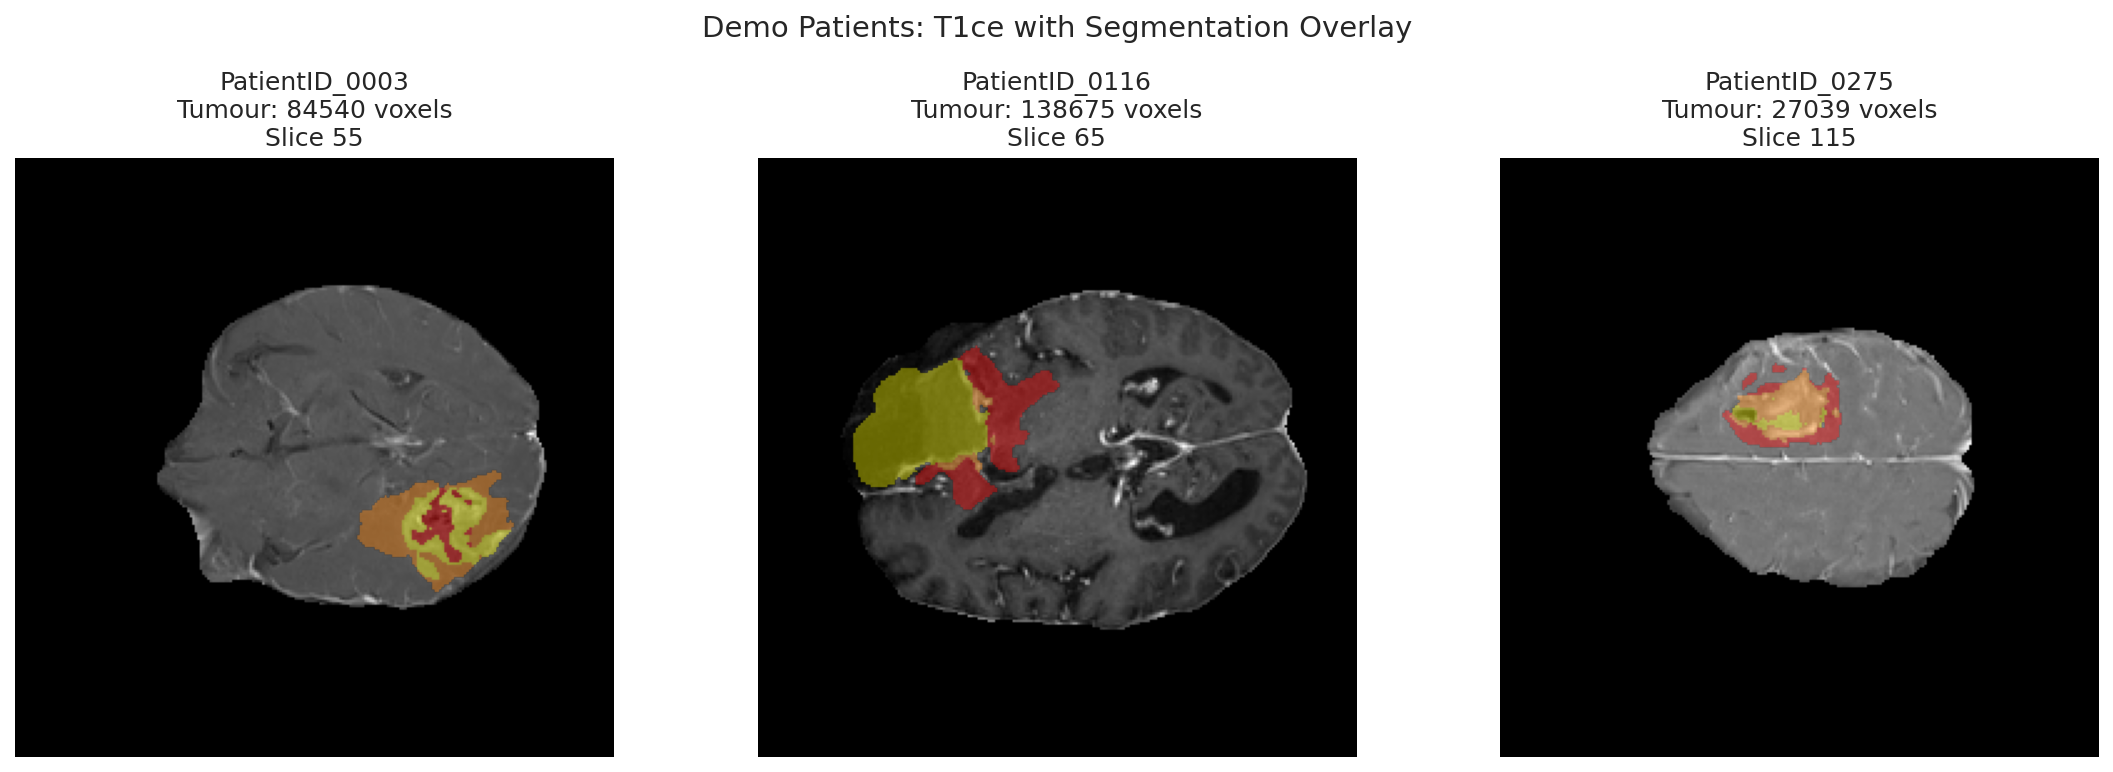

Saved: 06_demo_patients_overlay.png


In [30]:
# Visualise the demo patients: show middle axial slice of T1ce with segmentation overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, patient_id in enumerate(demo_patients):
    file_map = patient_file_registry[patient_id]

    # Load T1ce and segmentation
    t1c_img = nib.load(file_map['t1c'])
    seg_img = nib.load(file_map['seg'])
    t1c_data = t1c_img.get_fdata()
    seg_data = seg_img.get_fdata()

    # Find the axial slice with the most tumour voxels
    tumour_per_slice = np.sum(seg_data > 0, axis=(0, 1))
    best_slice = np.argmax(tumour_per_slice)

    # Display
    axes[idx].imshow(t1c_data[:, :, best_slice], cmap='gray')
    axes[idx].imshow(
        np.ma.masked_where(seg_data[:, :, best_slice] == 0, seg_data[:, :, best_slice]),
        cmap='autumn', alpha=0.4
    )
    tumour_volume = np.sum(seg_data > 0)
    axes[idx].set_title(f'{patient_id}\nTumour: {tumour_volume} voxels\nSlice {best_slice}',
                        fontsize=13, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Demo Patients: T1ce with Segmentation Overlay', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_demo_patients_overlay.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 06_demo_patients_overlay.png')

In [31]:
# Extract radiomic features for demo patients
# Create a temporary directory for binary masks
temp_dir = os.path.join(GLIOMA_DIR, 'temp_binary_masks')
os.makedirs(temp_dir, exist_ok=True)

demo_features_list = []
total_start = time.time()

for i, patient_id in enumerate(demo_patients):
    print(f'\nExtracting features for patient {i+1}/{len(demo_patients)}: {patient_id}')
    patient_start = time.time()

    features = extract_features_for_patient(
        patient_id=patient_id,
        file_map=patient_file_registry[patient_id],
        extractor=extractor,
        temp_dir=temp_dir
    )

    elapsed = time.time() - patient_start

    if features is not None:
        demo_features_list.append(features)
        n_features = len([k for k in features.keys() if k not in ('patient_id', 'tumour_voxels')])
        print(f'  Extracted {n_features} features in {elapsed:.1f}s')
    else:
        print(f'  FAILED after {elapsed:.1f}s')

total_elapsed = time.time() - total_start
print(f'\nTotal demo extraction time: {total_elapsed:.1f}s ({total_elapsed/60:.1f} min)')
print(f'Average per patient: {total_elapsed/len(demo_patients):.1f}s')

# Estimate full cohort time
avg_per_patient = total_elapsed / len(demo_patients)
full_estimate_mins = avg_per_patient * len(matched_patients) / 60
print(f'\nEstimated time for full cohort ({len(matched_patients)} patients): {full_estimate_mins:.0f} min')


Extracting features for patient 1/3: PatientID_0003


parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  Extracted 107 features in 4.0s

Extracting features for patient 2/3: PatientID_0116


parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  Extracted 107 features in 6.3s

Extracting features for patient 3/3: PatientID_0275


parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  Extracted 107 features in 3.2s

Total demo extraction time: 13.5s (0.2 min)
Average per patient: 4.5s

Estimated time for full cohort (202 patients): 15 min


In [32]:
# Convert demo features to DataFrame and inspect
demo_features_df = pd.DataFrame(demo_features_list)

# Separate metadata from actual radiomic features
metadata_cols = ['patient_id', 'tumour_voxels']
feature_cols = [c for c in demo_features_df.columns if c not in metadata_cols]

print(f'Demo features DataFrame: {demo_features_df.shape}')
print(f'Metadata columns: {len(metadata_cols)}')
print(f'Radiomic feature columns: {len(feature_cols)}')
print(f'\nFeature categories:')

# Count features by category
categories = {}
for col in feature_cols:
    # PyRadiomics names features as 'original_<class>_<feature>'
    parts = col.split('_')
    if len(parts) >= 2:
        category = parts[1] if parts[0] == 'original' else parts[0]
    else:
        category = 'other'
    categories[category] = categories.get(category, 0) + 1

for cat, count in sorted(categories.items()):
    print(f'  {cat}: {count} features')

Demo features DataFrame: (3, 109)
Metadata columns: 2
Radiomic feature columns: 107

Feature categories:
  firstorder: 18 features
  glcm: 24 features
  gldm: 14 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape: 14 features


In [33]:
# Save demo features
demo_features_df.to_csv(
    os.path.join(RESULTS_DIR, '06_demo_radiomic_features.csv'), index=False
)
print('Saved: 06_demo_radiomic_features.csv')

# Display a sample of features
print('\nSample of extracted features (first 10):')
demo_features_df[feature_cols[:10]].T

Saved: 06_demo_radiomic_features.csv

Sample of extracted features (first 10):


,0,1,2
original_shape_Elongation,0.788332,0.820336,0.265681
original_shape_Flatness,0.573500,0.609500,0.202484
original_shape_LeastAxisLength,38.106284,46.512079,30.807304
original_shape_MajorAxisLength,66.445121,76.311814,152.146648
original_shape_Maximum2DDiameterColumn,79.611557,76.164296,127.011810
original_shape_Maximum2DDiameterRow,66.573268,89.185201,131.685231
original_shape_Maximum2DDiameterSlice,67.186308,92.703829,49.040799
original_shape_Maximum3DDiameter,81.271151,98.442877,139.391535
original_shape_MeshVolume,84448.916667,138776.125000,26878.791667
original_shape_MinorAxisLength,52.380830,62.601290,40.422447


---
## 7. Full Cohort Extraction

> **Note:** Full cohort extraction was performed on CSF3. The cell below is retained for reference but should be skipped. Results are loaded from `06_full_radiomic_features.csv` in Section 8.

In [ ]:
# Full cohort extraction was performed on CSF3 using 06_pyradiomics_extraction_csf3.py
# Results are loaded from the CSV in Section 8
full_features_path = os.path.join(RESULTS_DIR, '06_full_radiomic_features.csv')
print(f'Full features path: {full_features_path}')
print(f'File exists: {os.path.exists(full_features_path)}')

Full features path: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/pyradiomics/results/06_full_radiomic_features.csv
File exists: True


---
## 8. Feature Quality Control

Before modelling, we clean the radiomic feature matrix:
1. Remove NaN/infinite values
2. Remove near-zero variance features
3. Remove highly correlated feature pairs (|r| > 0.95)

In [34]:
full_features_path = os.path.join(RESULTS_DIR, '06_full_radiomic_features.csv')
full_features_df = pd.read_csv(full_features_path)

In [35]:
# Separate metadata from features
metadata_cols = ['patient_id', 'tumour_voxels']
radiomics_df = full_features_df.copy()
feature_cols = [c for c in radiomics_df.columns if c not in metadata_cols]

print(f'Initial feature matrix: {radiomics_df.shape}')
print(f'Radiomic features: {len(feature_cols)}')

# Check for NaN and infinite values
nan_counts = radiomics_df[feature_cols].isna().sum()
inf_counts = np.isinf(radiomics_df[feature_cols].select_dtypes(include=[np.number])).sum()

print(f'\nFeatures with NaN values: {(nan_counts > 0).sum()}')
print(f'Features with Inf values: {(inf_counts > 0).sum()}')

# Drop features with any NaN or Inf
clean_features = feature_cols.copy()
for col in feature_cols:
    if radiomics_df[col].isna().any() or (np.isinf(radiomics_df[col]).any() if radiomics_df[col].dtype != object else False):
        clean_features.remove(col)

print(f'Features after NaN/Inf removal: {len(clean_features)}')

Initial feature matrix: (202, 109)
Radiomic features: 107

Features with NaN values: 0
Features with Inf values: 0
Features after NaN/Inf removal: 107


In [36]:
# Remove near-zero variance features
# A feature with variance < 1e-10 provides no discriminative power
feature_variances = radiomics_df[clean_features].var()
low_var_features = feature_variances[feature_variances < 1e-10].index.tolist()

clean_features = [f for f in clean_features if f not in low_var_features]

print(f'Near-zero variance features removed: {len(low_var_features)}')
if low_var_features:
    print(f'  Removed: {low_var_features}')
print(f'Features remaining: {len(clean_features)}')

Near-zero variance features removed: 0
Features remaining: 107


In [37]:
# Remove highly correlated features (|r| > 0.95)
# When two features are nearly identical, one is redundant
corr_matrix = radiomics_df[clean_features].corr().abs()

# Find pairs with |r| > 0.95
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# For each pair, drop the feature with the higher mean correlation to all others
to_drop = set()
for col in upper_tri.columns:
    highly_correlated = upper_tri.index[upper_tri[col] > 0.95].tolist()
    for correlated_feat in highly_correlated:
        # Keep the feature with lower average correlation to everything else
        mean_corr_col = corr_matrix[col].mean()
        mean_corr_feat = corr_matrix[correlated_feat].mean()
        if mean_corr_col > mean_corr_feat:
            to_drop.add(col)
        else:
            to_drop.add(correlated_feat)

clean_features = [f for f in clean_features if f not in to_drop]

print(f'Highly correlated features removed (|r| > 0.95): {len(to_drop)}')
print(f'Features remaining after all QC: {len(clean_features)}')

Highly correlated features removed (|r| > 0.95): 46
Features remaining after all QC: 61


In [38]:
clean_features

['original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_LeastAxisLength',
 'original_shape_MajorAxisLength',
 'original_shape_Maximum2DDiameterColumn',
 'original_shape_Maximum2DDiameterRow',
 'original_shape_Maximum2DDiameterSlice',
 'original_shape_Maximum3DDiameter',
 'original_shape_MinorAxisLength',
 'original_shape_Sphericity',
 'original_shape_SurfaceArea',
 'original_shape_SurfaceVolumeRatio',
 'original_firstorder_10Percentile',
 'original_firstorder_InterquartileRange',
 'original_firstorder_Kurtosis',
 'original_firstorder_Maximum',
 'original_firstorder_Minimum',
 'original_firstorder_Skewness',
 'original_firstorder_TotalEnergy',
 'original_firstorder_Uniformity',
 'original_glcm_ClusterProminence',
 'original_glcm_DifferenceEntropy',
 'original_glcm_Idmn',
 'original_glcm_Idn',
 'original_glcm_Imc1',
 'original_glcm_Imc2',
 'original_glcm_InverseVariance',
 'original_glcm_JointEnergy',
 'original_glcm_MCC',
 'original_glcm_MaximumProbability',
 'origina

---
## 9. Feature Exploration

Showing top 30 features by variance (out of 61 total)


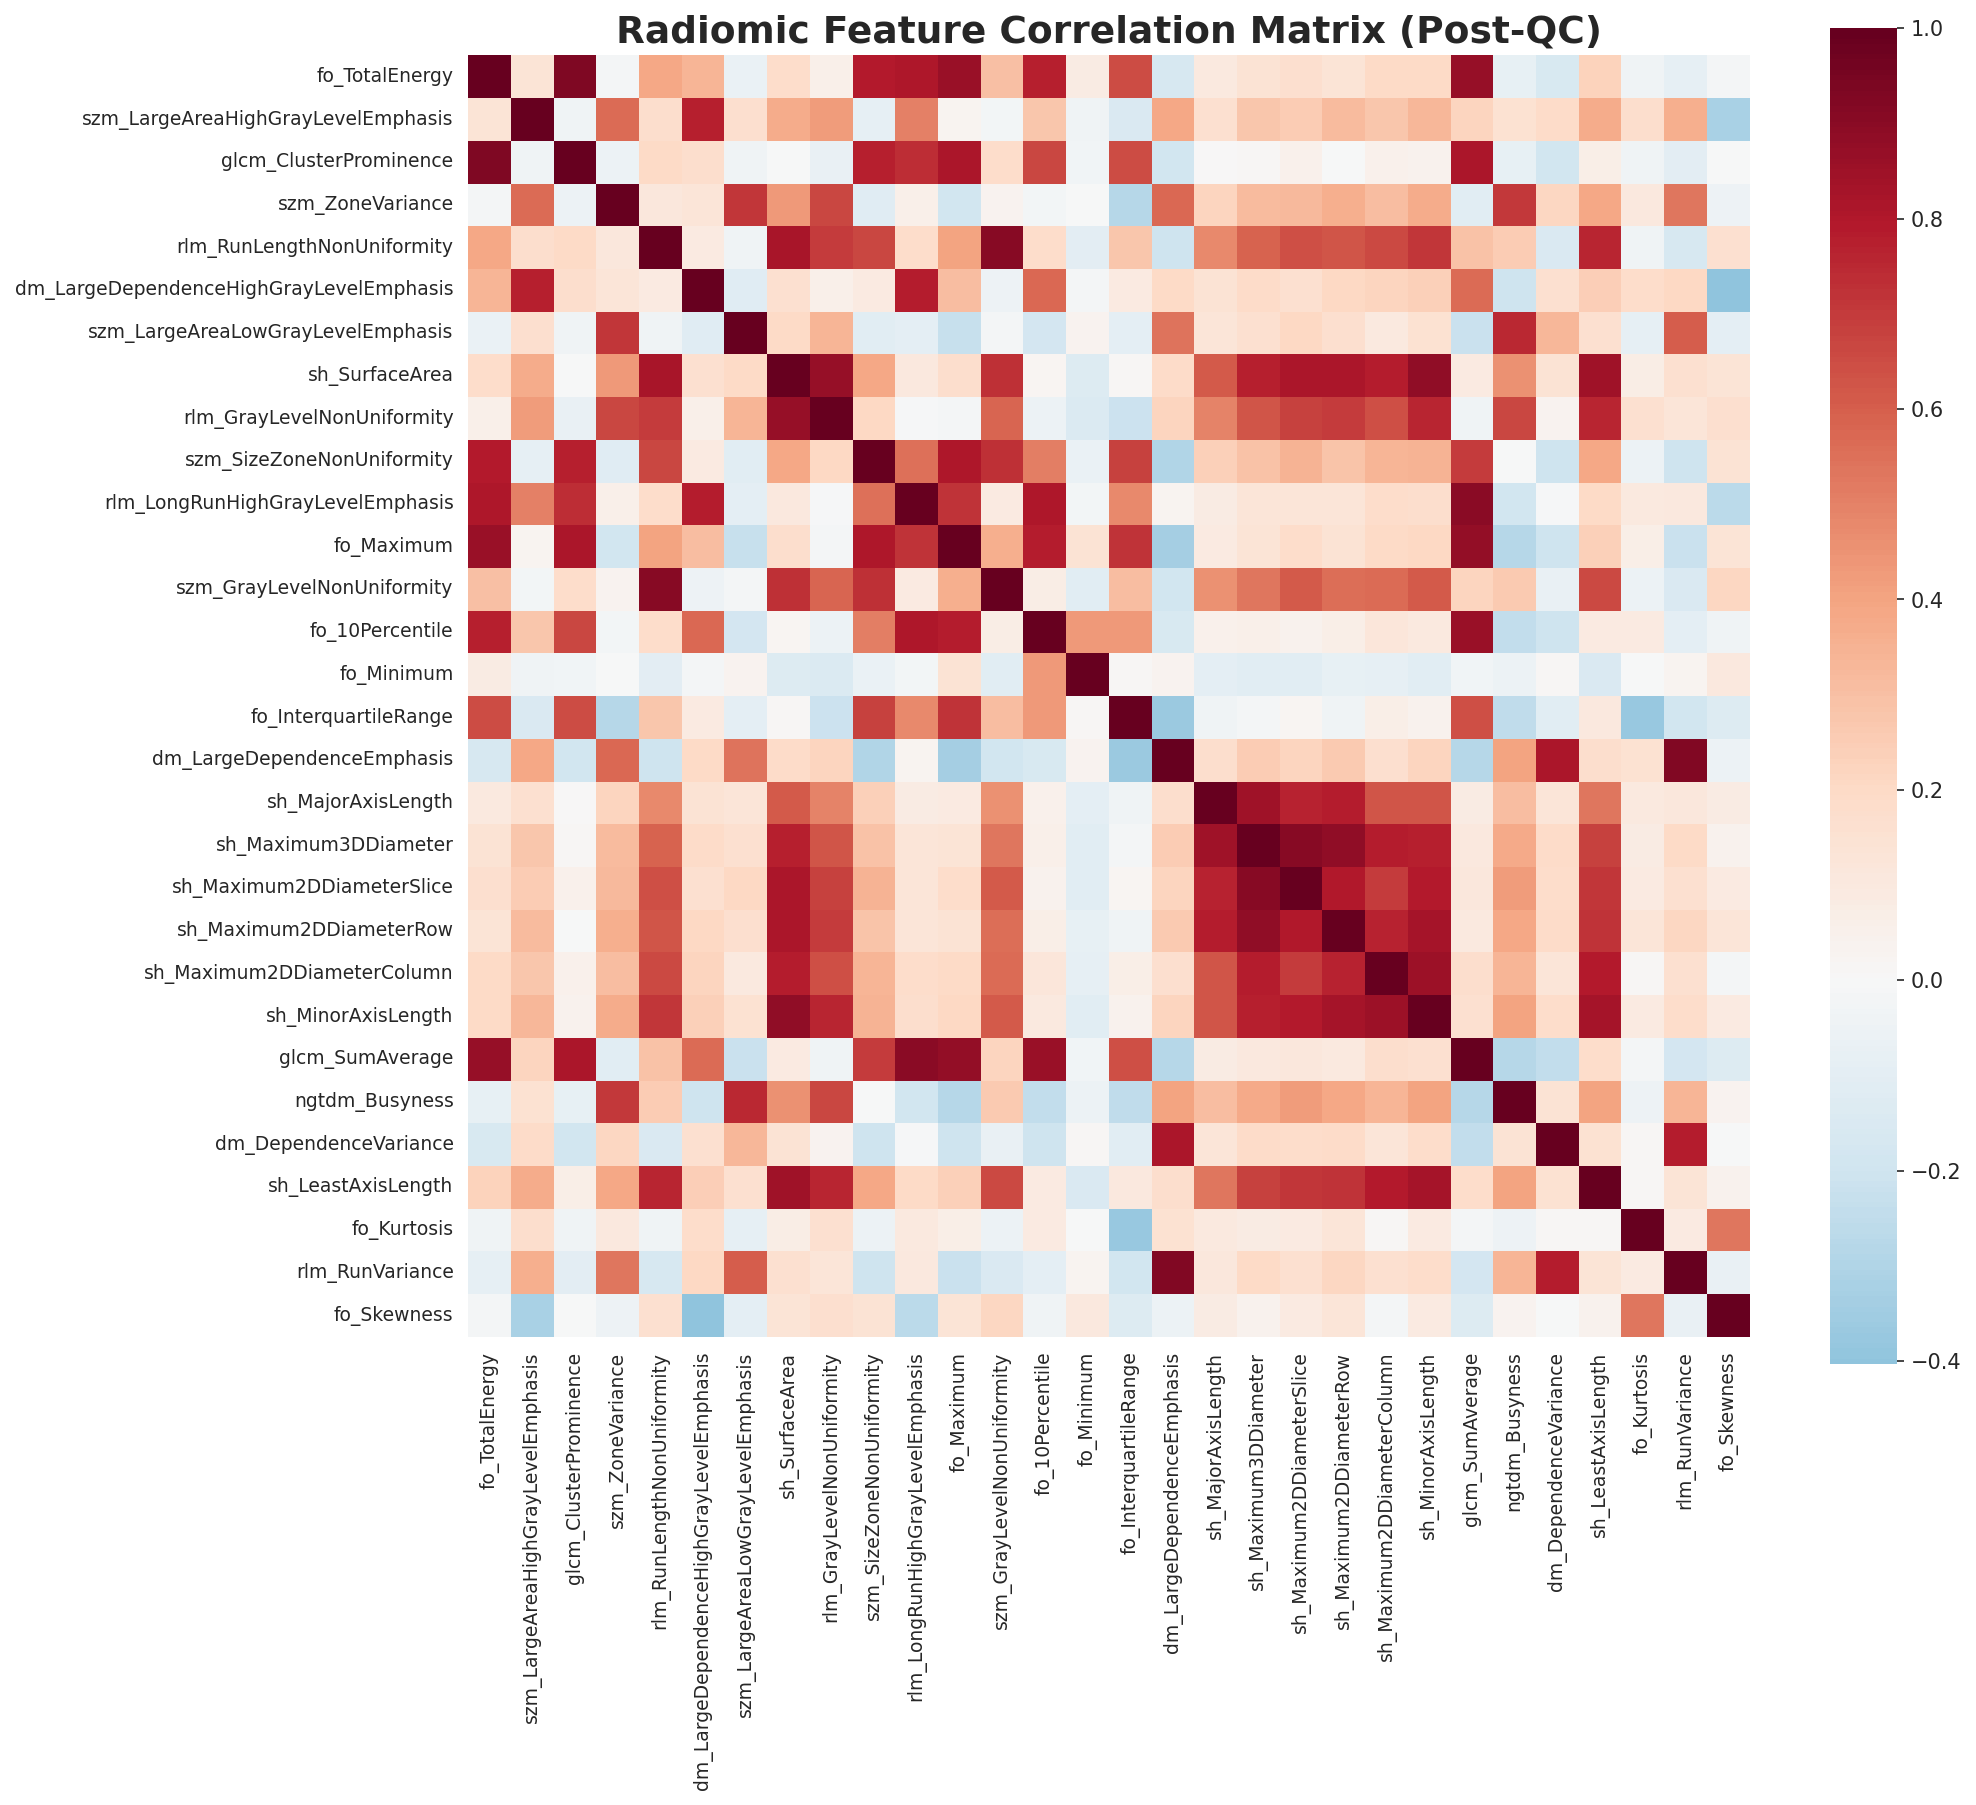

Saved: 06_feature_correlation_heatmap.pdf + .png


In [39]:
# Correlation heatmap of remaining features
# If >30 features, show only top 30 by variance for readability
plot_features = clean_features
if len(clean_features) > 30:
    top_var = radiomics_df[clean_features].var().nlargest(30).index.tolist()
    plot_features = top_var
    print(f'Showing top 30 features by variance (out of {len(clean_features)} total)')

fig, ax = plt.subplots(figsize=(14, 12))
corr_plot = radiomics_df[plot_features].corr()

# Shorten feature names for display
short_names = [f.replace('original_', '').replace('firstorder_', 'fo_')
                .replace('shape_', 'sh_').replace('glcm_', 'glcm_')
                .replace('glrlm_', 'rlm_').replace('glszm_', 'szm_')
                .replace('gldm_', 'dm_')
               for f in plot_features]

sns.heatmap(corr_plot, annot=False, cmap='RdBu_r', center=0,
            xticklabels=short_names, yticklabels=short_names,
            square=True, ax=ax)
ax.set_title('Radiomic Feature Correlation Matrix (Post-QC)', fontsize=18, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_feature_correlation_heatmap.pdf'),
            bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, '06_feature_correlation_heatmap.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 06_feature_correlation_heatmap.pdf + .png')

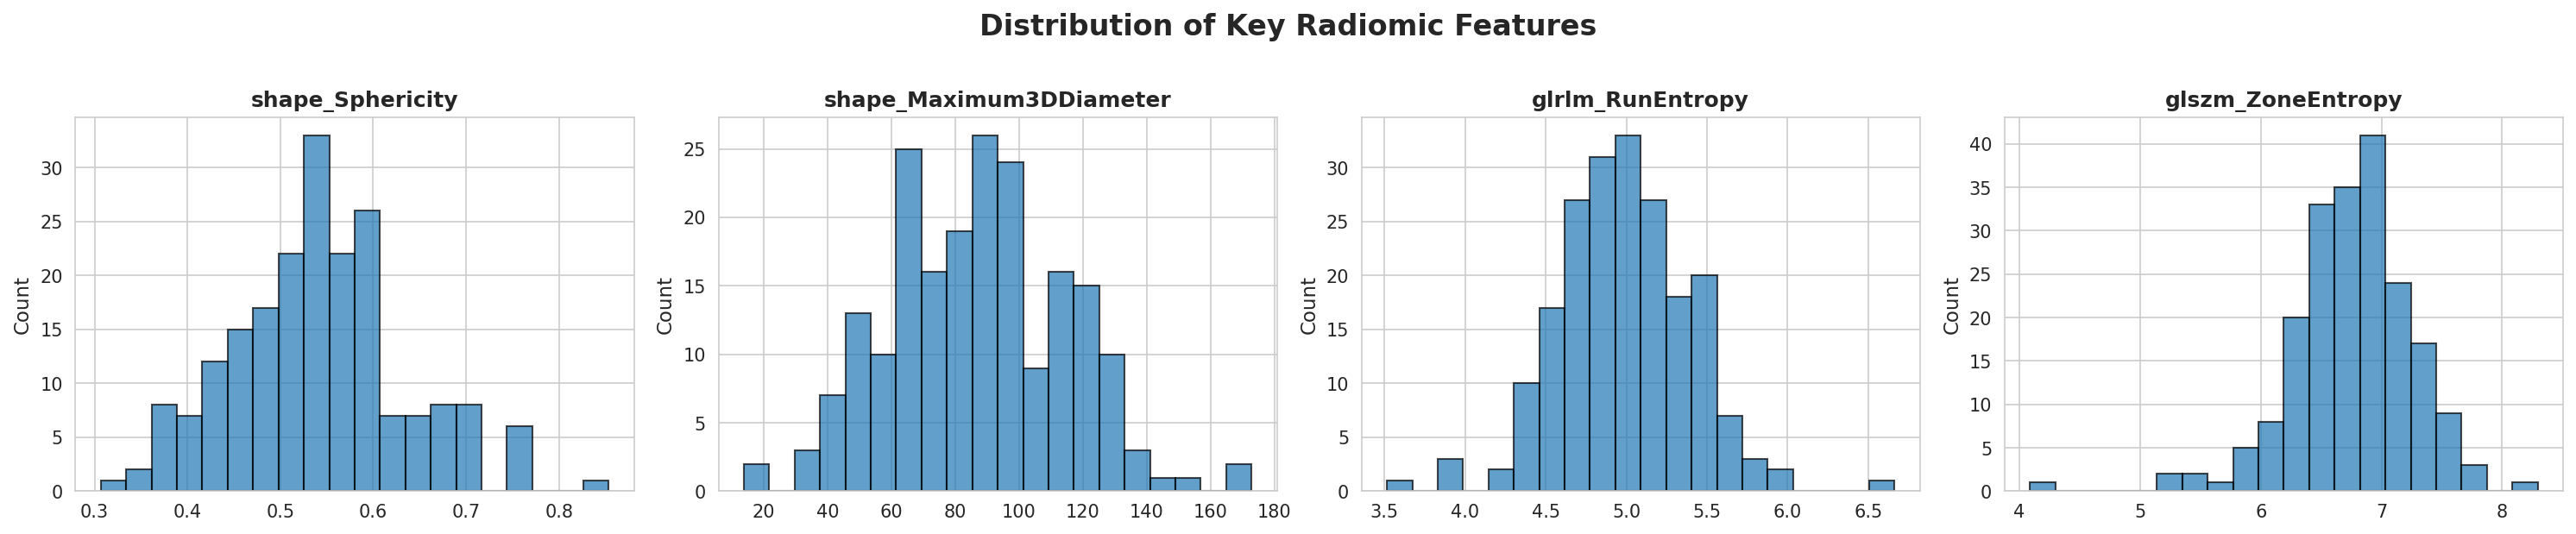

Saved: 06_key_feature_distributions.pdf + .png


In [40]:
# Distribution of key features
# Select representative features from each category if available
key_feature_candidates = [
    'original_firstorder_Entropy',
    'original_firstorder_Energy',
    'original_shape_Sphericity',
    'original_shape_Maximum3DDiameter',
    'original_glcm_Contrast',
    'original_glcm_JointEntropy',
    'original_glrlm_RunEntropy',
    'original_glszm_ZoneEntropy'
]

# Keep only those that exist in our feature set
key_features = [f for f in key_feature_candidates if f in clean_features]

if key_features:
    n_plots = len(key_features)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_2d(axes).flatten()

    for idx, feat in enumerate(key_features):
        short_name = feat.replace('original_', '')
        axes[idx].hist(radiomics_df[feat].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_title(short_name, fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].set_xlabel('')
        axes[idx].tick_params(labelsize=10)

    # Hide unused axes
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Distribution of Key Radiomic Features', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '06_key_feature_distributions.pdf'),
                bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_DIR, '06_key_feature_distributions.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: 06_key_feature_distributions.pdf + .png')
else:
    print('No key features found in cleaned feature set.')

---
## 10. Feature Selection (LASSO / Elastic Net)

With potentially 50-100+ features and only ~170 patients, we have a severe
p >> n problem. LASSO (L1 regularisation) forces most feature coefficients
to exactly zero, effectively selecting a sparse subset of informative features.

We use Elastic Net (L1 + L2 mix) because radiomic features are often correlated
in groups; pure LASSO would arbitrarily select one from each correlated group,
while Elastic Net tends to select entire groups.

**This section requires the full cohort extraction (Section 7).**
With only 3 demo patients, feature selection is not meaningful.

In [41]:
# Check dataset dimensions for feature selection
n_patients = len(radiomics_df)
n_features = len(clean_features)

print(f'Patients: {n_patients}')
print(f'Features: {n_features}')
print(f'Ratio (patients/features): {n_patients/n_features:.1f}')

Patients: 202
Features: 61
Ratio (patients/features): 3.3


In [42]:
# Merge radiomic features with survival outcome for feature selection
# Map patient IDs to the clinical data index
radiomics_merged = radiomics_df.copy()
radiomics_merged['patient_id_norm'] = radiomics_merged['patient_id'].apply(extract_patient_id)

# Get the binary outcome (y) aligned by patient ID
clinical_raw_indexed = clinical_raw.set_index(patient_id_col)

# Align: only keep patients present in both radiomics and clinical outcome
common_ids = set(radiomics_merged['patient_id_norm']) & set(clinical_raw_indexed.index.astype(str))
print(f'Patients with both radiomics and clinical outcome: {len(common_ids)}')

# Filter radiomics to matched patients
radiomics_for_selection = radiomics_merged[
    radiomics_merged['patient_id_norm'].isin(common_ids)
].copy()

# Build y_aligned by looking up survival outcome from clinical_raw for each radiomics patient
# The outcome column is 'Overall Survival (Death)' (binary: 0=alive, 1=dead)
outcome_col = None
for candidate in ['Overall Survival (Death)', 'overall survival (death)',
                  'Overall_Survival_Death', 'Vital Status']:
    if candidate in clinical_raw.columns:
        outcome_col = candidate
        break

if outcome_col is None:
    # Try case-insensitive match
    for col in clinical_raw.columns:
        if 'overall survival' in col.lower() and 'death' in col.lower():
            outcome_col = col
            break

if outcome_col is None:
    raise ValueError(f'Could not find survival outcome column. Available: {clinical_raw.columns.tolist()}')

print(f'Using outcome column: "{outcome_col}"')

# Create a lookup: patient_id -> outcome
outcome_lookup = clinical_raw_indexed[outcome_col].to_dict()

# Align outcome to radiomics patient order
y_aligned = radiomics_for_selection['patient_id_norm'].map(
    lambda pid: outcome_lookup.get(pid, outcome_lookup.get(int(pid.split('_')[-1]) if '_' in pid else pid))
).values.astype(float)

# Verify alignment
assert len(y_aligned) == len(radiomics_for_selection), \
    f'Alignment mismatch: {len(y_aligned)} outcomes vs {len(radiomics_for_selection)} patients'
assert not np.any(np.isnan(y_aligned)), \
    f'NaN outcomes found for {np.sum(np.isnan(y_aligned))} patients'

print(f'Radiomics patients for selection: {len(radiomics_for_selection)}')
print(f'Outcome variable aligned: {len(y_aligned)} (alive={int(np.sum(y_aligned==0))}, dead={int(np.sum(y_aligned==1))})')

Patients with both radiomics and clinical outcome: 202
Using outcome column: "Overall Survival (Death)"
Radiomics patients for selection: 202
Outcome variable aligned: 202 (alive=106, dead=96)


In [43]:
# Standardise features (zero mean, unit variance)
# Critical for LASSO; otherwise features on different scales dominate
X_radiomics = radiomics_for_selection[clean_features].values
scaler = StandardScaler()
X_radiomics_scaled = scaler.fit_transform(X_radiomics)

# Run Elastic Net with cross-validation to find optimal alpha
# l1_ratio=0.7 balances sparsity (L1) with grouping (L2)
elastic_net = ElasticNetCV(
    l1_ratio=0.7,
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=10000,
    n_alphas=100
)

# y_aligned was built in the previous cell via patient-ID-based lookup
elastic_net.fit(X_radiomics_scaled, y_aligned)

# Identify surviving features
coef_series = pd.Series(elastic_net.coef_, index=clean_features)
selected_features = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)

print(f'Elastic Net optimal alpha: {elastic_net.alpha_:.6f}')
print(f'Features surviving selection: {len(selected_features)} / {len(clean_features)}')
print(f'\nSelected features (ranked by |coefficient|):')
for feat, coef in selected_features.items():
    direction = '+' if coef > 0 else '-'
    short_name = feat.replace('original_', '')
    print(f'  {direction} {short_name}: {coef:.4f}')

Elastic Net optimal alpha: 0.049633
Features surviving selection: 8 / 61

Selected features (ranked by |coefficient|):
  + firstorder_Skewness: 0.0597
  + shape_SurfaceArea: 0.0392
  - gldm_SmallDependenceLowGrayLevelEmphasis: -0.0353
  + glrlm_RunLengthNonUniformity: 0.0290
  - glszm_LargeAreaLowGrayLevelEmphasis: -0.0213
  - glszm_SmallAreaLowGrayLevelEmphasis: -0.0137
  - glrlm_LongRunLowGrayLevelEmphasis: -0.0049
  - glszm_LowGrayLevelZoneEmphasis: -0.0027


Saved: 06_selected_radiomic_features.csv


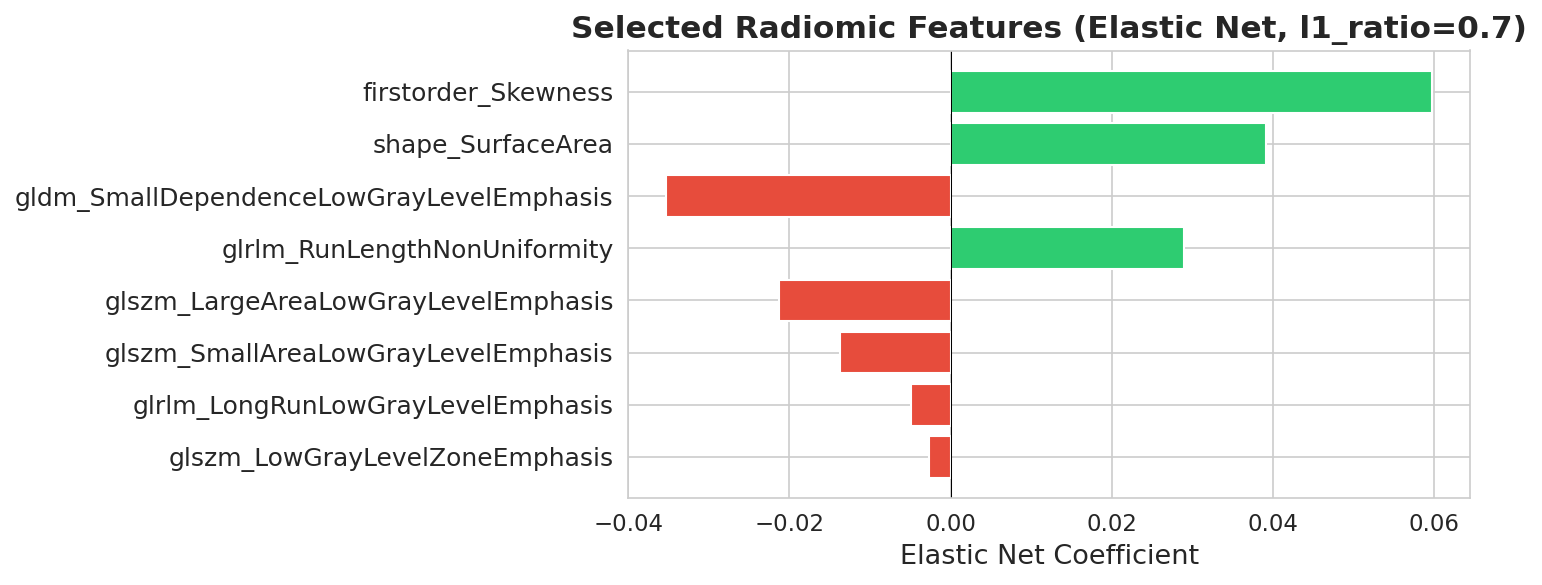

Saved: 06_selected_feature_coefficients.pdf + .png


In [44]:
if len(selected_features) > 0:
    # Save selected features
    selected_features.to_csv(
        os.path.join(RESULTS_DIR, '06_selected_radiomic_features.csv'),
        header=['coefficient']
    )
    print('Saved: 06_selected_radiomic_features.csv')

    # Visualise selected feature coefficients
    fig, ax = plt.subplots(figsize=(10, max(4, len(selected_features) * 0.5)))
    short_names = [f.replace('original_', '') for f in selected_features.index]
    colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in selected_features.values]

    ax.barh(range(len(selected_features)), selected_features.values, color=colors)
    ax.set_yticks(range(len(selected_features)))
    ax.set_yticklabels(short_names, fontsize=12)
    ax.set_xlabel('Elastic Net Coefficient', fontsize=13)
    ax.set_title('Selected Radiomic Features (Elastic Net, l1_ratio=0.7)', fontsize=15, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.tick_params(axis='x', labelsize=11)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '06_selected_feature_coefficients.pdf'),
                bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_DIR, '06_selected_feature_coefficients.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: 06_selected_feature_coefficients.pdf + .png')
else:
    print('No features selected; skipping visualisation.')

---
## 11. Predictive Modelling Comparison

We compare three conditions using the same XGBoost framework and 5-fold
stratified cross-validation as Notebook 02:

1. **Clinical features only** (baseline from Notebook 02; AUC ~0.674)
2. **Selected radiomics features only** (from Elastic Net above)
3. **Clinical + selected radiomics combined**

We do NOT re-tune hyperparameters; the point is to compare feature sets
under identical model conditions.

**This section requires full cohort extraction.**

> **Note:** The `evaluate_model` function previously defined here was unused — Cell 44 uses an inline `evaluate_simple` function instead. Removed to avoid confusion.

In [45]:
if len(selected_features) > 0:
    print('Model Comparison: Clinical vs Radiomics vs Combined')
    print('-' * 60)

    # Build clinical feature matrix aligned to the same patients as radiomics
    # X was created from high_fill_df with patient_id dropped, so we re-extract
    # clinical features from clinical_raw for the matched patients
    X_encoded = X.copy()
    for col in X_encoded.columns:
        if X_encoded[col].dtype == 'object':
            le = LabelEncoder()
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

    # Align clinical features to the same patients as radiomics_for_selection
    # X and y share the same integer index from high_fill_df (patient_id was dropped)
    # We need to map radiomics patients back to the X/y index via clinical_raw
    #
    # Strategy: for each patient in radiomics_for_selection, find their row in
    # clinical_raw, then find the corresponding row in high_fill_df/X by matching
    # on available columns (since patient_id was dropped from X).
    #
    # Simpler approach: rebuild clinical features from clinical_raw for matched patients
    # and use y_aligned (already aligned by patient ID in Cell 39)

    # Get clinical features for matched patients from X using the same patient ordering
    # We need the mapping: patient_id -> index in X/y
    # Since patient_id was dropped from X, we reconstruct via clinical_raw row order
    # clinical_raw and high_fill_df share the same row order (high_fill_df is filtered from clinical_raw)
    clinical_raw_with_idx = clinical_raw.copy()
    clinical_raw_with_idx['_pid_norm'] = clinical_raw_with_idx[patient_id_col].astype(str)

    # Build mapping from normalised patient ID to X/y integer index
    # X's index matches high_fill_df's index, which is a subset of clinical_raw's rows
    pid_to_xy_idx = {}
    for xy_idx, pid in zip(X.index, clinical_raw_with_idx.loc[X.index, '_pid_norm']):
        pid_to_xy_idx[pid] = xy_idx

    # Get X rows aligned to radiomics_for_selection patient order
    aligned_xy_indices = []
    for pid in radiomics_for_selection['patient_id_norm']:
        if pid in pid_to_xy_idx:
            aligned_xy_indices.append(pid_to_xy_idx[pid])

    X_clinical_aligned = X_encoded.loc[aligned_xy_indices].values

    print(f'Clinical features aligned: {X_clinical_aligned.shape}')
    print(f'Radiomics features: {len(radiomics_for_selection)}')

    # Simple evaluation function
    def evaluate_simple(X_data, y_data, name):
        model = XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss'
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='roc_auc')
        print(f'{name}: AUC = {scores.mean():.3f} +/- {scores.std():.3f}')
        return {'name': name, 'mean': scores.mean(), 'std': scores.std(), 'folds': scores}

    results = []

    # 1. Clinical only (using aligned patients)
    result_clinical = evaluate_simple(X_clinical_aligned, y_aligned, 'Clinical Only')
    results.append(result_clinical)

    # 2. Radiomics only
    selected_feat_names = selected_features.index.tolist()
    X_radiomics_selected = radiomics_for_selection[selected_feat_names].values
    result_radiomics = evaluate_simple(X_radiomics_selected, y_aligned, 'Radiomics Only')
    results.append(result_radiomics)

    # 3. Combined
    X_combined = np.hstack([X_clinical_aligned, X_radiomics_selected])
    result_combined = evaluate_simple(X_combined, y_aligned, 'Clinical + Radiomics')
    results.append(result_combined)

    # Statistical test
    t_stat, p_value = stats.ttest_rel(result_combined['folds'], result_clinical['folds'])
    print(f'\nPaired t-test (Combined vs Clinical): t={t_stat:.3f}, p={p_value:.4f}')

else:
    results = []
    print('Skipping model comparison.')

Model Comparison: Clinical vs Radiomics vs Combined
------------------------------------------------------------
Clinical features aligned: (202, 28)
Radiomics features: 202
Clinical Only: AUC = 0.742 +/- 0.112
Radiomics Only: AUC = 0.598 +/- 0.151
Clinical + Radiomics: AUC = 0.725 +/- 0.080

Paired t-test (Combined vs Clinical): t=-0.391, p=0.7157


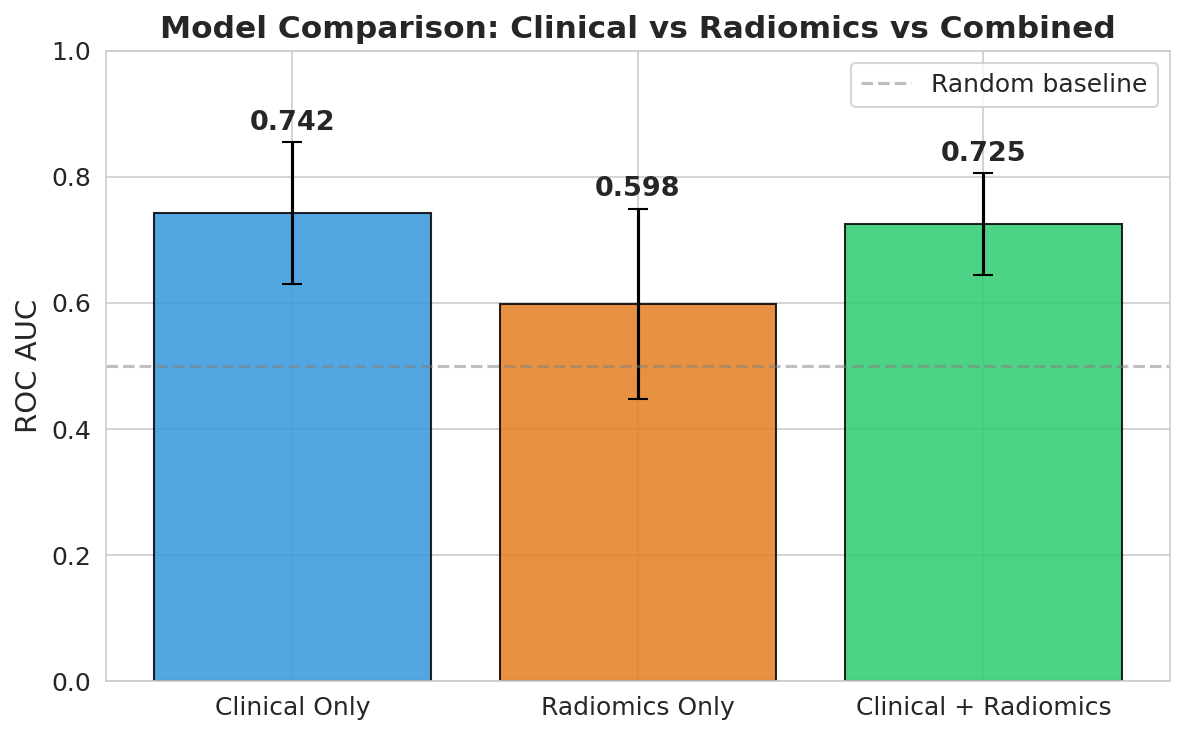

Saved: 06_model_comparison_barplot.pdf + .png


In [46]:
if results:
    # Model comparison barplot
    fig, ax = plt.subplots(figsize=(8, 5))

    model_names = [r['name'] for r in results]
    auc_means = [r['mean'] for r in results]
    auc_stds = [r['std'] for r in results]

    bars = ax.bar(model_names, auc_means, yerr=auc_stds,
                  capsize=5, color=['#3498db', '#e67e22', '#2ecc71'],
                  edgecolor='black', alpha=0.85)

    # Add value labels on bars
    for bar, mean, std in zip(bars, auc_means, auc_stds):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

    ax.set_ylabel('ROC AUC', fontsize=14)
    ax.set_title('Model Comparison: Clinical vs Radiomics vs Combined', fontsize=15, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.tick_params(labelsize=12)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '06_model_comparison_barplot.pdf'),
                bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_DIR, '06_model_comparison_barplot.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: 06_model_comparison_barplot.pdf + .png')
else:
    print('No results to plot.')

---
## 12. Biological Interpretation

If radiomic features were selected, we examine whether they have biological meaning:
- High GLCM entropy suggests tissue heterogeneity (aggressive tumour)
- Low sphericity suggests irregular infiltration patterns
- High GLRLM run entropy indicates fine-grained texture (cellular heterogeneity)

We also stratify patients by the top radiomic feature using a Kaplan-Meier
analysis to visualise whether it separates survival outcomes.

In [47]:
if len(selected_features) > 0:
    # Top radiomic feature for KM stratification
    top_feature = selected_features.index[0]
    top_feature_short = top_feature.replace('original_', '')
    print(f'Top selected radiomic feature: {top_feature_short}')
    print(f'  Elastic Net coefficient: {selected_features.iloc[0]:.4f}')

    # Median split for stratification
    feature_values = radiomics_for_selection[top_feature].values
    median_val = np.median(feature_values)
    high_group = feature_values >= median_val
    low_group = feature_values < median_val

    print(f'  Median value: {median_val:.4f}')
    print(f'  High group: {high_group.sum()} patients')
    print(f'  Low group: {low_group.sum()} patients')

    # Biological interpretation based on feature category
    if 'glcm' in top_feature.lower():
        print(f'\n  Interpretation: GLCM features capture spatial intensity relationships.')
        print(f'  This suggests tumour texture heterogeneity contributes to prognosis.')
    elif 'shape' in top_feature.lower():
        print(f'\n  Interpretation: Shape features describe tumour morphology.')
        print(f'  Irregular shapes may indicate infiltrative growth patterns.')
    elif 'firstorder' in top_feature.lower():
        print(f'\n  Interpretation: First-order features describe intensity distribution.')
        print(f'  This suggests intensity heterogeneity is prognostically relevant.')
    elif 'glrlm' in top_feature.lower() or 'glszm' in top_feature.lower():
        print(f'\n  Interpretation: Run-length/size-zone features capture regional patterns.')
        print(f'  This may reflect spatial organisation of necrosis or viable tissue.')
else:
    print('No features selected; skipping biological interpretation.')

Top selected radiomic feature: firstorder_Skewness
  Elastic Net coefficient: 0.0597
  Median value: 1.0800
  High group: 101 patients
  Low group: 101 patients

  Interpretation: First-order features describe intensity distribution.
  This suggests intensity heterogeneity is prognostically relevant.


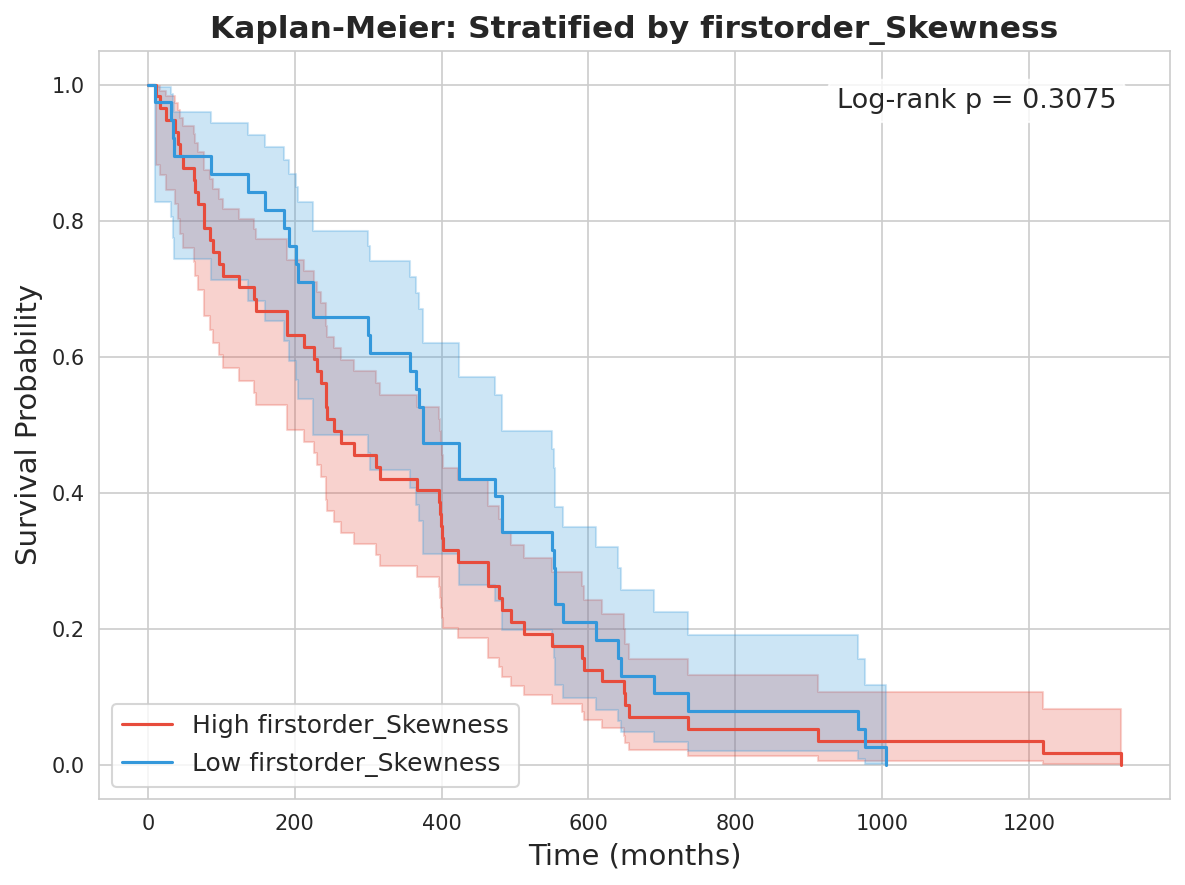

Saved: 06_km_top_radiomic_feature.pdf + .png


In [48]:
# Kaplan-Meier stratification by top radiomic feature
# This requires survival time and event data
# We use lifelines for KM estimation if available

if len(selected_features) > 0:
    try:
        from lifelines import KaplanMeierFitter
        from lifelines.statistics import logrank_test

        # Load survival data
        # This needs to be aligned with the radiomics patients
        # Adjust the column names based on your clinical data structure
        survival_col = None
        event_col = None

        for candidate in ['Number of days from Diagnosis to death (Days)', 'Overall Survival (Months)', 'survival_months', 'os_months']:
            if candidate in clinical_raw.columns:
                survival_col = candidate
                break

        for candidate in ['Overall Survival (Death)', 'Vital Status', 'vital_status', 'event']:
            if candidate in clinical_raw.columns:
                event_col = candidate
                break

        if survival_col and event_col:
            # Align survival data with radiomics patients
            km_data = clinical_raw.set_index(patient_id_col).loc[
                radiomics_for_selection['patient_id_norm'].values
            ][[survival_col, event_col]].copy()

            # Convert event to binary (1=dead, 0=censored)
            if km_data[event_col].dtype == object:
                km_data['event'] = km_data[event_col].str.lower().map(
                    {'dead': 1, 'alive': 0, '1': 1, '0': 0}
                ).fillna(0).astype(int)
            else:
                km_data['event'] = km_data[event_col].astype(int)

            km_data['survival'] = pd.to_numeric(km_data[survival_col], errors='coerce')
            km_data['group'] = np.where(high_group, f'High {top_feature_short}',
                                                     f'Low {top_feature_short}')

            # Drop missing survival data
            km_data = km_data.dropna(subset=['survival', 'event'])

            # Plot KM curves
            fig, ax = plt.subplots(figsize=(8, 6))
            kmf = KaplanMeierFitter()

            for group_name, color in [(f'High {top_feature_short}', '#e74c3c'),
                                     (f'Low {top_feature_short}', '#3498db')]:
                mask = km_data['group'] == group_name
                if mask.sum() > 0:
                    kmf.fit(
                        km_data.loc[mask, 'survival'],
                        km_data.loc[mask, 'event'],
                        label=group_name
                    )
                    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

            # Log-rank test
            high_mask = km_data['group'].str.startswith('High')
            if high_mask.sum() > 0 and (~high_mask).sum() > 0:
                lr_result = logrank_test(
                    km_data.loc[high_mask, 'survival'],
                    km_data.loc[~high_mask, 'survival'],
                    km_data.loc[high_mask, 'event'],
                    km_data.loc[~high_mask, 'event']
                )
                ax.text(0.95, 0.95, f'Log-rank p = {lr_result.p_value:.4f}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=13, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            ax.set_xlabel('Time (months)', fontsize=14)
            ax.set_ylabel('Survival Probability', fontsize=14)
            ax.set_title(f'Kaplan-Meier: Stratified by {top_feature_short}', fontsize=15, fontweight='bold')
            ax.legend(fontsize=12)

            plt.tight_layout()
            plt.savefig(os.path.join(FIGURES_DIR, '06_km_top_radiomic_feature.pdf'),
                        bbox_inches='tight')
            plt.savefig(os.path.join(FIGURES_DIR, '06_km_top_radiomic_feature.png'),
                        dpi=300, bbox_inches='tight')
            plt.show()
            print('Saved: 06_km_top_radiomic_feature.pdf + .png')
        else:
            print(f'Could not find survival/event columns in clinical data.')
            print(f'Available columns: {clinical_raw.columns.tolist()}')

    except ImportError:
        print('lifelines not installed. Install with: pip install lifelines')
        print('Skipping Kaplan-Meier analysis.')

else:
    print('No features selected; skipping KM analysis.')

---
## 13. Summary and Export

In [49]:
# Summary variables are set from the notebook execution above

In [50]:
# Summary of all results
print('NOTEBOOK 06 SUMMARY: Comprehensive Radiomic Feature Extraction')
print('-' * 70)

print(f'\n1. Data')
print(f'   Patient directories scanned: {len(all_patient_dirs)}')
print(f'   Patients with T1ce + segmentation: {len(patient_file_registry)}')
print(f'   Patients matched with clinical data: {len(overlap)}')

print(f'\n2. Feature Extraction')
print(f'   Total radiomic features extracted: {len(feature_cols)}')
print(f'   After QC (NaN, variance, correlation): {len(clean_features)}')

print(f'\n3. Feature Selection')
if 'selected_features' in dir() and len(selected_features) > 0:
    print(f'   Method: Elastic Net (l1_ratio=0.7, 5-fold CV)')
    print(f'   Features selected: {len(selected_features)} / {len(clean_features)}')
    for feat in selected_features.index[:5]:
        print(f'     - {feat.replace("original_", "")}')
else:
    print(f'   No features selected')

print(f'\n4. Model Comparison')
if results:
    for r in results:
        name = r.get("model_name", r.get("name", "Unknown"))
        mean = r.get("auc_mean", r.get("mean", 0))
        std = r.get("auc_std", r.get("std", 0))
        print(f'   {name}: AUC = {mean:.3f} +/- {std:.3f}')
else:
    print(f'   Not run')

print(f'\n5. Saved Outputs')
for f in sorted(os.listdir(RESULTS_DIR)):
    if f.startswith('06_'):
        print(f'   results/{f}')
for f in sorted(os.listdir(FIGURES_DIR)):
    if f.startswith('06_'):
        print(f'   figures/{f}')

NOTEBOOK 06 SUMMARY: Comprehensive Radiomic Feature Extraction
----------------------------------------------------------------------

1. Data
   Patient directories scanned: 203
   Patients with T1ce + segmentation: 202
   Patients matched with clinical data: 202

2. Feature Extraction
   Total radiomic features extracted: 107
   After QC (NaN, variance, correlation): 61

3. Feature Selection
   Method: Elastic Net (l1_ratio=0.7, 5-fold CV)
   Features selected: 8 / 61
     - firstorder_Skewness
     - shape_SurfaceArea
     - gldm_SmallDependenceLowGrayLevelEmphasis
     - glrlm_RunLengthNonUniformity
     - glszm_LargeAreaLowGrayLevelEmphasis

4. Model Comparison
   Clinical Only: AUC = 0.742 +/- 0.112
   Radiomics Only: AUC = 0.598 +/- 0.151
   Clinical + Radiomics: AUC = 0.725 +/- 0.080

5. Saved Outputs
   results/06_demo_radiomic_features.csv
   results/06_full_radiomic_features.csv
   results/06_full_radiomic_features.gsheet
   results/06_pyradiomics_results.json
   results/06_

In [51]:
# Save complete results as JSON
summary_results = {
    'notebook': '06_pyradiomics_feature_extraction',
    'data': {
        'total_patient_dirs': len(all_patient_dirs),
        'patients_with_imaging': len(patient_file_registry),
        'patients_matched': len(overlap),
        'demo_patients': demo_patients
    },
    'features': {
        'total_extracted': len(feature_cols),
        'after_qc': len(clean_features),
        'selected': len(selected_features) if 'selected_features' in dir() else 'N/A'
    },
    'model_comparison': [
        {'model': r.get('model_name', r.get('name')),
        'auc_mean': r.get('auc_mean', r.get('mean')),
        'auc_std': r.get('auc_std', r.get('std'))}
        for r in results
    ] if results else 'Not run (demo mode)',
    'extractor_settings': {
        'binWidth': extractor_settings['binWidth'],
        'label': extractor_settings['label'],
        'image_types': ['Original'],
        'feature_classes': ['firstorder', 'shape', 'glcm', 'glrlm', 'glszm', 'gldm']
    }
}

with open(os.path.join(RESULTS_DIR, '06_pyradiomics_results.json'), 'w') as f:
    json.dump(summary_results, f, indent=2, default=str)

print('Saved: 06_pyradiomics_results.json')

Saved: 06_pyradiomics_results.json


In [52]:
# Clean up temporary directory
import shutil
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
    print(f'Cleaned up temporary directory: {temp_dir}')

print('\nNotebook 06 complete.')

Cleaned up temporary directory: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/temp_binary_masks

Notebook 06 complete.
